# Used Car Price Prediction - Data Preprocessing

## Objective
The objective of this notebook is to clean and preprocess the CarsDekho dataset before performing Exploratory Data Analysis (EDA) and training machine learning models.

## Workflow
1. Import libraries
2. Load the dataset
3. Explore the dataset
4. Clean and preprocess the data
5. Save the cleaned dataset

In [1]:
import pandas as pd
import numpy as np

STEP 1 - Load the dataset

In [2]:
df=pd.read_csv("../data/raw/cars_details_merged.csv")

C:\Users\divya singh\AppData\Local\Temp\ipykernel_32396\408865552.py:1: DtypeWarning: Columns (0: priceSaving, 1: brandingIcon) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("../data/raw/cars_details_merged.csv")


STEP 2 - Understanding the dataset

In [3]:
df.shape

(37814, 140)

### Observation

- The dataset contains **37,814 rows**, meaning information for 37,814 used cars.
- It has **140 columns**, representing different attributes of each car.
- Since not all features are useful for predicting price, feature selection will be performed during preprocessing.

STEP 3 - Previewing the data

In [4]:
df.head()

,position,loc,myear,bt,tt,ft,km,ip,pi,images,...,owner_type,price_segment_new,template_name_new,page_template,template_Type_new,experiment,Fuel Suppy System,Compression Ratio,Alloy Wheel Size,Ground Clearance Unladen
0,1,Gomti Nagar,2016,Hatchback,Manual,CNG,"69,162",0,https://images10.gaadi.com/usedcar_image/origi...,[{'img': 'https://images10.gaadi.com/usedcar_i...,...,first,2lakh-5lakh,used cardetail v2/corporate/13,Used Car > Detail Page,used,control,NaN,NaN,NaN,NaN
1,2,Borivali West,2015,Hatchback,Manual,CNG,"45,864",0,https://images10.gaadi.com/usedcar_image/origi...,[{'img': 'https://images10.gaadi.com/usedcar_i...,...,first,2lakh-5lakh,used cardetail v2/corporate/13,Used Car > Detail Page,used,control,Intelligent-Gas Port Injection,11.0:1,NaN,NaN
2,3,JASOLA,2015,Sedan,Manual,CNG,"81,506",0,https://images10.gaadi.com/usedcar_image/origi...,[{'img': 'https://images10.gaadi.com/usedcar_i...,...,second,2lakh-5lakh,used cardetail v2/corporate/13,Used Car > Detail Page,used,control,NaN,NaN,NaN,NaN
3,4,jasola,2013,Hatchback,Manual,CNG,"1,15,893",0,NaN,[{'img': ''}],...,second,2lakh-5lakh,used cardetail v2/corporate/13,Used Car > Detail Page,used,control,MPFI,NaN,13,NaN
4,5,mumbai g.p.o.,2022,MUV,Manual,CNG,"18,900",0,https://images10.gaadi.com/usedcar_image/origi...,[{'img': 'https://images10.gaadi.com/usedcar_i...,...,first,10+lakh,used cardetail v2,Used Car > Detail Page,used,control,NaN,12.0+-.03,NaN,NaN


## Step 4: Inspect Data Types and Missing Values

The `info()` function provides information about the dataset, including the number of non-null values, data types of each column, and memory usage.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37814 entries, 0 to 37813
Columns: 140 entries, position to Ground Clearance Unladen
dtypes: bool(3), float64(10), int64(28), str(99)
memory usage: 39.6 MB


In [6]:
df.info(verbose=True,show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 37814 entries, 0 to 37813
Data columns (total 140 columns):
 #    Column                    Non-Null Count  Dtype  
---   ------                    --------------  -----  
 0    position                  37814 non-null  int64  
 1    loc                       31963 non-null  str    
 2    myear                     37814 non-null  int64  
 3    bt                        37795 non-null  str    
 4    tt                        37814 non-null  str    
 5    ft                        37814 non-null  str    
 6    km                        37814 non-null  str    
 7    ip                        37814 non-null  int64  
 8    pi                        37134 non-null  str    
 9    images                    37814 non-null  str    
 10   imgCount                  37814 non-null  int64  
 11   threesixty                37814 non-null  bool   
 12   dvn                       37814 non-null  str    
 13   oem                       37814 non-null  str    
 14  

In [9]:
df.columns.tolist()

['position',
 'loc',
 'myear',
 'bt',
 'tt',
 'ft',
 'km',
 'ip',
 'pi',
 'images',
 'imgCount',
 'threesixty',
 'dvn',
 'oem',
 'model',
 'modelId',
 'vid',
 'centralVariantId',
 'variantName',
 'city_x',
 'vlink',
 'price',
 'pu',
 'discountValue',
 'msp',
 'priceSaving',
 'pageNo',
 'utype',
 'views',
 'usedCarId',
 'usedCarSkuId',
 'ucid',
 'sid',
 'tmGaadiStore',
 'emiwidget',
 'transmissionType',
 'dynx_itemid_x',
 'dynx_itemid2_x',
 'dynx_totalvalue_x',
 'leadForm',
 'leadFormCta',
 'offers',
 'compare',
 'brandingIcon',
 'pageType',
 'carType',
 'corporateId',
 'top_features',
 'comfort_features',
 'interior_features',
 'exterior_features',
 'safety_features',
 'Color',
 'Engine Type',
 'Displacement',
 'Max Power',
 'Max Torque',
 'No of Cylinder',
 'Values per Cylinder',
 'Value Configuration',
 'BoreX Stroke',
 'Turbo Charger',
 'Super Charger',
 'Length',
 'Width',
 'Height',
 'Wheel Base',
 'Front Tread',
 'Rear Tread',
 'Kerb Weight',
 'Gross Weight',
 'Gear Box',
 'Drive

## Column Strategy

We classify all features into:
1. Target variable
2. Identifiers (drop)
3. UI / metadata (drop)
4. Redundant features (keep one)
5. Useful predictive features (keep)

In [10]:
df[['price', 'pu']].head(10)

,price,pu
0,₹ 3.70 Lakh,"3,70,000"
1,₹ 3.65 Lakh,"3,65,000"
2,₹ 4.21 Lakh,"4,21,000"
3,₹ 2.40 Lakh,"2,40,000"
4,₹ 11.75 Lakh,"11,75,000"
5,₹ 2.50 Lakh,"2,50,000"
6,₹ 1.45 Lakh,"1,45,000"
7,₹ 4.65 Lakh,"4,65,000"
8,₹ 5.60 Lakh,"5,60,000"
9,₹ 2.15 Lakh,"2,15,000"


In [11]:
df["pu"].head(10)

0     3,70,000
1     3,65,000
2     4,21,000
3     2,40,000
4    11,75,000
5     2,50,000
6     1,45,000
7     4,65,000
8     5,60,000
9     2,15,000
Name: pu, dtype: str

In [12]:
df["pu"] = df["pu"].str.replace(",", "").astype(int)

In [13]:
df["pu"].dtype

dtype('int64')

STEP 5 - Dropping a few columns 

In [14]:
cols_to_drop = [
    "position",
    "usedCarId",
    "usedCarSkuId",
    "ucid",
    "sid",
    "images",
    "imgCount",
    "threesixty",
    "vlink",
    "pageNo",
    "views",
    "leadForm",
    "offers",
    "brandingIcon",
    "page_title",
    "template_name_new",
    "experiment",
    "dynx_itemid_x",
    "dynx_itemid_y",
    "dynx_totalvalue_x"
]

df = df.drop(columns=cols_to_drop)

In [17]:
missing_ratio= df.isnull().mean().sort_values(ascending=False)
missing_ratio.head(15)

compare_car_details         1.000000
originalLocation            1.000000
priceSaving                 0.999947
Ground Clearance Unladen    0.943090
Compression Ratio           0.730999
BoreX Stroke                0.665812
Gross Weight                0.552441
Rear Tread                  0.419845
Front Tread                 0.419818
Top Speed                   0.397631
Acceleration                0.369916
Alloy Wheel Size            0.347649
Kerb Weight                 0.347464
Value Configuration         0.207093
Cargo Volumn                0.178029
dtype: float64

dropping more columns - jiska missing ratio is greater than 0.9

In [18]:
missing_ratio = df.isnull().mean().sort_values(ascending=False)

cols_to_drop = missing_ratio[missing_ratio >= 0.99].index

df = df.drop(columns=cols_to_drop)

df.shape

(37814, 117)

dropping few more columns based off of missing values and inconsistent data

In [22]:
high_missing_cols = [
    "Ground Clearance Unladen",
    "Compression Ratio",
    "BoreX Stroke",
    "Gross Weight"
]

df = df.drop(columns=high_missing_cols)

df.shape

(37814, 113)

just displaying 3 similar columns to check 

In [23]:
df[["ft","fuel_type","fuel_type_new"]]

,ft,fuel_type,fuel_type_new
0,CNG,cng,cng
1,CNG,cng,cng
2,CNG,cng,cng
3,CNG,cng,cng
4,CNG,cng,cng
...,...,...,...
37809,Diesel,diesel,diesel
37810,Diesel,diesel,diesel
37811,Diesel,diesel,diesel
37812,Diesel,diesel,diesel


In [24]:
(df["ft"].str.lower()==df["fuel_type"]).all()

np.False_

In [25]:
df = df.drop(columns=["ft", "fuel_type"])

In [27]:
duplicate_cols = [
    "ft",
    "tt",
    "myear",
    "model",
    "variantName",
    "city_x",
    "fuel_type",
    "transmissionType",
    "transmission_type",
    "model_year",
    "model_name",
    "oem",
    "variant_new",
    "brand_new",
    "city_y",
    "used_carid",
    "dealer_id"
]

df = df.drop(columns=duplicate_cols, errors="ignore")

df.shape

(37814, 96)

Remove website, tracking, marketing, and UI columns

In [28]:
metadata_cols = [
    "ip",
    "pi",
    "dvn",
    "discountValue",
    "msp",
    "utype",
    "tmGaadiStore",
    "emiwidget",
    "leadFormCta",
    "compare",
    "pageType",
    "carType",
    "corporateId",
    "seller_type_new",
    "price_range_segment",
    "dealer_id_new",
    "city_id_new",
    "page_type",
    "price_segment",
    "dynx_event",
    "dynx_pagetype",
    "dynx_itemid2_x",
    "dynx_itemid2_y",
    "dynx_totalvalue_y",
    "price_segment_new",
    "template_name_new",
    "page_template",
    "template_Type_new",
    "experiment"
]

df = df.drop(columns=metadata_cols, errors="ignore")

df.shape

(37814, 69)

In [29]:
df.columns.tolist()

['loc',
 'bt',
 'km',
 'modelId',
 'vid',
 'centralVariantId',
 'price',
 'pu',
 'top_features',
 'comfort_features',
 'interior_features',
 'exterior_features',
 'safety_features',
 'Color',
 'Engine Type',
 'Displacement',
 'Max Power',
 'Max Torque',
 'No of Cylinder',
 'Values per Cylinder',
 'Value Configuration',
 'Turbo Charger',
 'Super Charger',
 'Length',
 'Width',
 'Height',
 'Wheel Base',
 'Front Tread',
 'Rear Tread',
 'Kerb Weight',
 'Gear Box',
 'Drive Type',
 'Seating Capacity',
 'Steering Type',
 'Turning Radius',
 'Front Brake Type',
 'Rear Brake Type',
 'Top Speed',
 'Acceleration',
 'Tyre Type',
 'No Door Numbers',
 'Cargo Volumn',
 'model_type_new',
 'seating_capacity_new',
 'model_year_new',
 'car_type_new',
 'model_id_new',
 'oem_name',
 'state',
 'max_engine_capacity_new',
 'transmission_type_new',
 'km_driven',
 'model_new',
 'vehicle_type_new',
 'brand_name',
 'engine_cc',
 'fuel_type_new',
 'car_segment',
 'city_name_new',
 'engine_capacity_new',
 'body_type_

In [30]:
drop_more = [
    "price",
    "modelId",
    "vid",
    "centralVariantId",
    "model_id_new",
    "Seating Capacity",
    "owner_type"
]

df = df.drop(columns=drop_more)

df.shape

(37814, 62)

In [31]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 37814 entries, 0 to 37813
Data columns (total 62 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   loc                      31963 non-null  str    
 1   bt                       37795 non-null  str    
 2   km                       37814 non-null  str    
 3   pu                       37814 non-null  int64  
 4   top_features             37814 non-null  str    
 5   comfort_features         37814 non-null  str    
 6   interior_features        37814 non-null  str    
 7   exterior_features        37814 non-null  str    
 8   safety_features          37814 non-null  str    
 9   Color                    37654 non-null  str    
 10  Engine Type              36946 non-null  str    
 11  Displacement             37761 non-null  float64
 12  Max Power                37583 non-null  str    
 13  Max Torque               37583 non-null  str    
 14  No of Cylinder           37671 no

In [32]:
df[[
    "km",
    "Max Power",
    "Max Torque",
    "engine_cc",
    "engine_capacity_new",
    "mileage_new"
]].head(10)

,km,Max Power,Max Torque,engine_cc,engine_capacity_new,mileage_new
0,"69,162",58.16bhp@6200rpm,77Nm@3500rpm,500cc-1000cc,500cc-1000cc,26.6 kmpl
1,"45,864",58.2bhp@6000rpm,78Nm@3500rpm,500cc-1000cc,500cc-1000cc,31.79 kmpl
2,"81,506",86.7bhp@6000rpm,109Nm@4500rpm,1000cc-2000cc,1000cc-2000cc,18 kmpl
3,"1,15,893",58.2bhp@6200rpm,77Nm@3500rpm,500cc-1000cc,500cc-1000cc,26.2 kmpl
4,"18,900",86.63bhp@5500rpm,121.5nm@4200rpm,1000cc-2000cc,1000cc-2000cc,26.11 km/kg
5,"60,000",58.16bhp@6200rpm,77Nm@3500rpm,500cc-1000cc,500cc-1000cc,26.6 kmpl
6,"67,000",38.4bhp@6200rpm,62Nm@3000rpm,500cc-1000cc,500cc-1000cc,26.83 kmpl
7,"58,000",65.39bhp@6000rpm,98Nm@4000rpm,1000cc-2000cc,1000cc-2000cc,18.9 km/kg
8,"54,097",58.33bhp@5500rpm,78Nm@3500rpm,500cc-1000cc,500cc-1000cc,32.52 kmpl
9,"67,000",58.16bhp@6200rpm,77Nm@3500rpm,500cc-1000cc,500cc-1000cc,26.6 kmpl


converting text to integer 

In [33]:
df["km"] = df["km"].str.replace(",", "").astype(int)

In [34]:
df["km"].dtype

dtype('int64')

Current values look like:

58.16bhp@6200rpm
86.7bhp@6000rpm

For price prediction, we only care about the horsepower, not the RPM.

We want:

58.16
86.7

In [35]:
df["Max Power"] = (
    df["Max Power"]
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)

In [36]:
df["Max Power"].head()

0    58.16
1    58.20
2    86.70
3    58.20
4    86.63
Name: Max Power, dtype: float64

In [37]:
# Extract torque value and convert it to a numeric column
df["Max Torque"] = (
    df["Max Torque"]
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)
df["Max Torque"].head()

0     77.0
1     78.0
2    109.0
3     77.0
4    121.5
Name: Max Torque, dtype: float64

In [38]:
# Extract mileage value and convert it to numeric
df["mileage_new"] = (
    df["mileage_new"]
    .str.extract(r"(\d+\.?\d*)")[0]
    .astype(float)
)
df["mileage_new"].head()

0    26.60
1    31.79
2    18.00
3    26.20
4    26.11
Name: mileage_new, dtype: float64

In [39]:
# Convert dimension columns to numeric values

dimension_cols = ["Length", "Width", "Height", "Wheel Base"]

for col in dimension_cols:
    df[col] = (
        df[col]
        .str.extract(r"(\d+\.?\d*)")[0]
        .astype(float)
    )
    df[["Length", "Width", "Height", "Wheel Base"]].head()

In [40]:
df[["Length", "Width", "Height", "Wheel Base"]].head()

,Length,Width,Height,Wheel Base
0,3599.0,1495.0,1700.0,2400.0
1,3600.0,1600.0,1560.0,2425.0
2,3990.0,1680.0,1505.0,2405.0
3,3595.0,1475.0,1700.0,2400.0
4,4395.0,1735.0,1690.0,2740.0


In [41]:
# Convert remaining measurement columns to numeric

numeric_cols = [
    "Front Tread",
    "Rear Tread",
    "Kerb Weight",
    "Turning Radius",
    "Top Speed",
    "Acceleration",
    "Cargo Volumn",
    "Alloy Wheel Size"
]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.extract(r"(\d+\.?\d*)")[0]
    )

df[numeric_cols] = df[numeric_cols].astype(float)

In [42]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]

Rear Tread                 15876
Front Tread                15875
Top Speed                  15352
Acceleration               13988
Alloy Wheel Size           13146
Kerb Weight                13139
Value Configuration         7831
Cargo Volumn                6732
loc                         5851
Turning Radius              5848
Fuel Suppy System           5502
Super Charger               5348
Drive Type                  4496
Turbo Charger               2176
mileage_new                  901
Engine Type                  868
Steering Type                808
Wheel Base                   556
Gear Box                     407
Width                        371
Height                       363
Length                       362
Front Brake Type             327
Rear Brake Type              326
Tyre Type                    257
Max Torque                   231
Max Power                    231
Values per Cylinder          228
engine_cc                    161
engine_capacity_new          161
Color     

In [43]:
drop_cols = [
    "Front Tread",
    "Rear Tread",
    "Top Speed",
    "Acceleration",
    "Kerb Weight",
    "Alloy Wheel Size"
]

df = df.drop(columns=drop_cols)

df.shape

(37814, 56)

In [44]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]

Value Configuration        7831
Cargo Volumn               6732
loc                        5851
Turning Radius             5848
Fuel Suppy System          5502
Super Charger              5348
Drive Type                 4496
Turbo Charger              2176
mileage_new                 901
Engine Type                 868
Steering Type               808
Wheel Base                  556
Gear Box                    407
Width                       371
Height                      363
Length                      362
Front Brake Type            327
Rear Brake Type             326
Tyre Type                   257
Max Torque                  231
Max Power                   231
Values per Cylinder         228
engine_cc                   161
engine_capacity_new         161
Color                       160
No of Cylinder              143
exterior_color              123
Displacement                 53
min_engine_capacity_new      53
max_engine_capacity_new      53
No Door Numbers              44
seating_

In [45]:
cols = [
    "Value Configuration",
    "Drive Type",
    "Fuel Suppy System",
    "Turbo Charger",
    "Super Charger"
]

for col in cols:
    print(f"\n{'='*50}")
    print(col)
    print(df[col].value_counts(dropna=False).head(10))


Value Configuration
Value Configuration
DOHC                    23064
NaN                      7831
SOHC                     6200
DOHC                      439
undefined                 121
iDSI                       66
DOHC with VIS              31
DOHC with VGT              20
16 Modules 48 Cells        11
16-valve DOHC layout        9
Name: count, dtype: int64

Drive Type
Drive Type
FWD     27240
NaN      4496
RWD      2248
AWD      1082
2WD       642
4WD       570
2 WD      369
4X2       254
FWD       217
4X4       216
Name: count, dtype: int64

Fuel Suppy System
Fuel Suppy System
MPFI                9530
NaN                 5502
CRDi                4632
CRDI                4507
MPFi                3716
Direct Injection    3545
PGM-Fi               771
PGM - Fi             570
Common Rail          457
GDi                  437
Name: count, dtype: int64

Turbo Charger
Turbo Charger
No       20174
Yes      15162
NaN       2176
Twin       120
YES         96
NO          47
no          

In [46]:
# Standardize categorical values

df["Turbo Charger"] = (
    df["Turbo Charger"]
    .str.strip()
    .str.title()
)

df["Super Charger"] = (
    df["Super Charger"]
    .str.strip()
    .str.title()
)

df["Fuel Suppy System"] = (
    df["Fuel Suppy System"]
    .str.upper()
)

df["Drive Type"] = (
    df["Drive Type"]
    .str.replace(" ", "", regex=False)
    .str.upper()
)

In [47]:
print(df["Turbo Charger"].value_counts(dropna=False).head(10))

print(df["Super Charger"].value_counts(dropna=False).head(10))

print(df["Drive Type"].value_counts(dropna=False).head(10))

print(df["Fuel Suppy System"].value_counts(dropna=False).head(10))

Turbo Charger
No       20247
Yes      15263
NaN       2176
Twin       125
Turbo        3
Name: count, dtype: int64
Super Charger
No     32368
NaN     5348
Yes       98
Name: count, dtype: int64
Drive Type
FWD                27457
NaN                 4496
RWD                 2248
AWD                 1082
2WD                 1017
4WD                  577
4X2                  297
4X4                  229
FRONTWHEELDRIVE      176
TWOWHEELDRIVE         98
Name: count, dtype: int64
Fuel Suppy System
MPFI                              13274
CRDI                               9139
NaN                                5502
DIRECT INJECTION                   3564
PGM-FI                              882
PGM - FI                            570
COMMON RAIL                         457
GDI                                 455
MPI                                 374
EFI(ELECTRONIC FUEL INJECTION)      365
Name: count, dtype: int64


In [50]:
# Fill missing values

# Numerical columns -> median
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns -> mode
cat_cols = df.select_dtypes(include=["object", "string"]).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [51]:
df.dtypes.value_counts()

str        36
float64    16
int64       4
Name: count, dtype: int64

In [52]:
import os

os.makedirs("../data/processed", exist_ok=True)

df.to_csv("../data/processed/cleaned_cars.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [53]:
os.listdir("../data/processed")

['cleaned_cars.csv']

Each cell contains a list of features. For example:

ABS, Bluetooth, Airbags, Rear Camera

Instead of giving the model a long string of text, we'll tell it:

"This car has 4 comfort/safety features."

In [54]:
feature_cols = [
    "top_features",
    "comfort_features",
    "interior_features",
    "exterior_features",
    "safety_features"
]

for col in feature_cols:
    df[col + "_count"] = (
        df[col]
        .astype(str)
        .apply(lambda x: len([item for item in x.split(",") if item.strip()]))
    )

df.drop(columns=feature_cols, inplace=True)

In [55]:
df.columns.tolist()

['loc',
 'bt',
 'km',
 'pu',
 'Color',
 'Engine Type',
 'Displacement',
 'Max Power',
 'Max Torque',
 'No of Cylinder',
 'Values per Cylinder',
 'Value Configuration',
 'Turbo Charger',
 'Super Charger',
 'Length',
 'Width',
 'Height',
 'Wheel Base',
 'Gear Box',
 'Drive Type',
 'Steering Type',
 'Turning Radius',
 'Front Brake Type',
 'Rear Brake Type',
 'Tyre Type',
 'No Door Numbers',
 'Cargo Volumn',
 'model_type_new',
 'seating_capacity_new',
 'model_year_new',
 'car_type_new',
 'oem_name',
 'state',
 'max_engine_capacity_new',
 'transmission_type_new',
 'km_driven',
 'model_new',
 'vehicle_type_new',
 'brand_name',
 'engine_cc',
 'fuel_type_new',
 'car_segment',
 'city_name_new',
 'engine_capacity_new',
 'body_type_new',
 'owner_type_new',
 'mileage_new',
 'variant_name',
 'exterior_color',
 'min_engine_capacity_new',
 'Fuel Suppy System',
 'top_features_count',
 'comfort_features_count',
 'interior_features_count',
 'exterior_features_count',
 'safety_features_count']

In [57]:
df["pu"].describe()

count    3.781400e+04
mean     7.999749e+05
std      3.043006e+06
min      1.196300e+04
25%      3.200000e+05
50%      5.250000e+05
75%      8.552040e+05
max      5.500006e+08
Name: pu, dtype: float64

finding outliers by boxplot 

Matplotlib is building the font cache; this may take a moment.


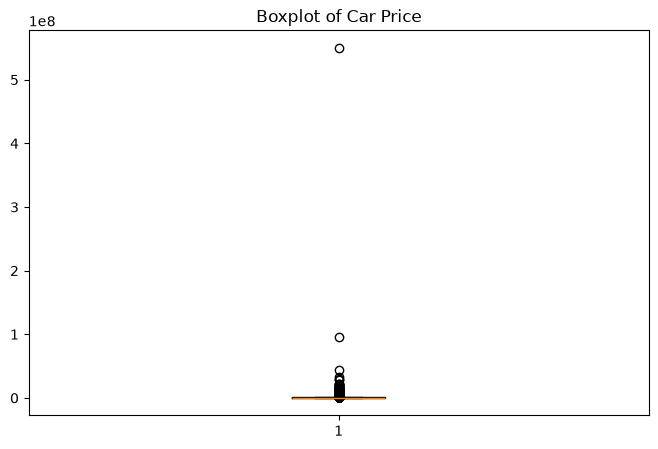

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.boxplot(df["pu"])
plt.title("Boxplot of Car Price")
plt.show()

removing 2 rows with absurd values

In [60]:
df[df["pu"] > 5_00_00_000]

,loc,bt,km,pu,Color,Engine Type,Displacement,Max Power,Max Torque,No of Cylinder,...,mileage_new,variant_name,exterior_color,min_engine_capacity_new,Fuel Suppy System,top_features_count,comfort_features_count,interior_features_count,exterior_features_count,safety_features_count
5091,Pune City,SUV,75000,550000555,White,TDCi Diesel Engine,1498.0,98.59,205.0,4.0,...,22.77,ford ecosport 1.5 tdci titanium bsiv,White,1498.0,DIRECT INJECTION,9,16,13,13,20
13638,Pune City,Sedan,15000,95519530,White,V12 Petrol Engine,6749.0,563.00,900.0,12.0,...,9.80,rolls-royce phantom extended wheelbase,White,6749.0,DIRECT INJECTION,9,30,19,21,40


In [61]:
df = df[df["pu"] < 5_00_00_000]
df["pu"].max()
df.shape

(37812, 56)

updating our cleared dataset after additional commads

In [62]:
df.to_csv("../data/processed/cleaned_cars.csv", index=False)

print("Updated cleaned dataset saved successfully!")

Updated cleaned dataset saved successfully!
